In [ ]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['NanumGothic']


In [ ]:
df = pd.read_csv('21_cmapss_fd001_sample.csv')
print(df.shape)

sensors = ['s_2', 's_3', 's_4', 's_7', 's_11']

(1031, 10)


## 실습 1. 상관관계 heatmap 해석하기
여러 센서의 상관을 색으로 그려 관계 파악

목표
- 여러 센서의 상관 heatmap을 그려 함께 움직이는 센서를 색으로 파악

단계
- 다섯 센서의 상관행렬을 계산
- 히트맵으로 색과 숫자를 함께 표시
- 대각선을 빼고 진한 칸을 강한 관계로 읽기

예상 결과
- 진한 칸이 강한 양·음 상관, s_2와 s_4가 가장 진함

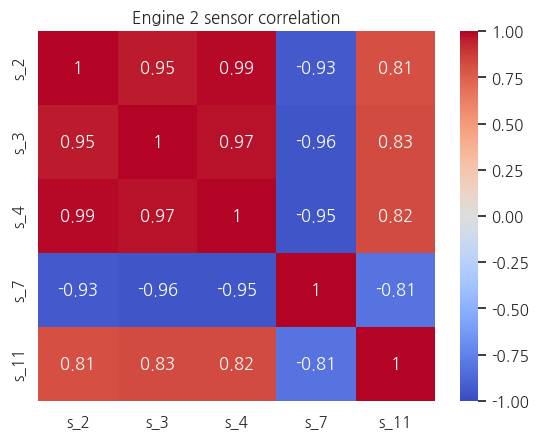

In [ ]:
# [2번 엔진의 주요 센서 간 상관관계 행렬 시각화]
# 1. sns.heatmap(): 2번 엔진 센서 간 상관관계의 크기를 색상 강도로 매핑하고, 수치 값을 셀에 오버레이합니다.
# 2. vmin=-1, vmax=1: 색상 범위를 피어슨 상관계수 한계치인 -1(완벽한 음)부터 +1(완벽한 양)로 제한하여 왜곡을 없앱니다.
# * 어떤 센서들이 서로 완전히 똑같이 행동하는지(예: s_2와 s_4가 약 0.99로 극도의 양의 상관),
#   어떤 센서가 서로 상반되는 움직임을 띄는지 파악하여 향후 고장 모델 입력 피처 선택의 우선순위를 결정합니다.
# * 히트맵을 렌더링하고 `plt.close()`를 수행해야 다음 실습 도화지와 격리되어 이미지가 혼선 없이 깔끔하게 저장됩니다.

e2 = df[df['unit_nr'] == 2].reset_index(drop=True)
sns.heatmap(e2[sensors].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Engine 2 sensor correlation')
plt.show()

## 실습 2. 강하게 연동된 센서 묶음 찾기
상관 절대값이 큰 센서쌍만 골라 핵심 묶음 식별

목표
- 상관 절대값이 큰 센서쌍만 골라 핵심 연동 묶음을 식별

단계
- 상관행렬에서 두 센서씩 짝지어 상관을 확인
- 절대값이 0.9 이상인 쌍만 골라내기
- 양의 묶음과 음의 묶음으로 나눠 정리

예상 결과
- s_2·s_3·s_4가 강한 양의 묶음, s_7은 이들과 음의 관계

In [ ]:
# [중첩 루프(Nested Loop)를 이용한 고상관 센서 조합 자동 식별]
# 1. 이중 for 루프: 행렬의 대각 성분을 기준으로 우상단 삼각형 영역만 순회하여 중복 매칭을 사전에 피합니다 (`j = i + 1` 기법).
# 2. abs(c) >= 0.9: 양의 상관과 음의 상관을 아울러 절댓값 0.9 이상의 초강력 상호작용을 가진 센서 쌍만 발라냅니다.
# * 설비 진단 엔지니어가 수많은 측정 지표 속에서 동조하는 물리량 묶음(예: 온도 상승과 입력 마찰의 동시 증가)을
#   수작업 대신 코드로 즉시 식별하여 물리적 다중공선성 문제를 계량적으로 제어하기 위해 활용됩니다.
# * `iloc[i, j]`를 조회할 때 인덱서 변수의 대소문자나 오타에 주의하고,
#   중복 출력을 피하려면 안쪽 루프의 시작점 j가 반드시 `i + 1`이 되도록 코딩해야 합니다.

corr = e2[sensors].corr()
for i in range(len(sensors)):
    for j in range(i + 1, len(sensors)):
        c = corr.iloc[i, j]
        if abs(c) >= 0.9:
            print(sensors[i], '-', sensors[j], ':', round(c, 2))


s_2 - s_3 : 0.95
s_2 - s_4 : 0.99
s_2 - s_7 : -0.93
s_3 - s_4 : 0.97
s_3 - s_7 : -0.96
s_4 - s_7 : -0.95


## 실습 3. 이상 의심 구간 표시하기
이동표준편차로 변동성을 추적하고 의심 구간 색칠

목표
- 이동표준편차로 변동성을 추적하고 의심 구간을 색으로 표시

단계
- 창 크기 20으로 이동표준편차를 구하기
- 위칸에 원본, 아래칸에 이동표준편차를 그리기
- 변동성이 커지는 후반 구간을 색 영역으로 표시

예상 결과
- 후반 구간에서 이동표준편차가 치솟고 색칠된 의심 구간과 겹침

In [ ]:
# [axvspan을 이용한 시계열 이상 의심 구간 시각적 음영 하이라이트]
# 1. std20: 20-사이클 이동표준편차 변동성 시리즈를 정의합니다.
# 2. ax1.axvspan(265, 287): x축의 265 사이클부터 287 사이클까지의 배경에 옅은 빨간색 영역(Span)을 생성합니다.
# 3. sharex=True: 위아래 두 서브플롯의 가로축을 강제 바인딩하여 마우스 줌이나 플로팅 범위를 동기화합니다.
# * 엔진이 수명 임계치 근처에 다다라 급격한 진동(이동표준편차 피크)을 나타내는 고장 임박 구간을
#   관람자에게 직관적이고 경고 효과를 주기 위해 차트에 음영으로 배경을 도포해 줍니다.
# * `alpha=0.15`와 같이 투명도를 낮추지 않고 불투명하게(1.0) 그리면
#   배경이 원본 그래프 선을 완전히 덮어써 보이지 않게 되는 실수가 흔히 발생합니다.

std20 = e2['s_3'].rolling(20).std()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax1.plot(e2['time_cycles'], e2['s_3'])
ax1.axvspan(265, 287, color='red', alpha=0.15)
ax1.set_title('s_3 raw with suspect zone')

ax2.plot(e2['time_cycles'], std20, color='red')
ax2.axvspan(265, 287, color='red', alpha=0.15)
ax2.set_title('s_3 moving std(20)')

plt.tight_layout()
plt.show()

## 실습 4. 정상 범위 벗어난 점 찾기
평균과 표준편차로 정상 범위를 만들고 벗어난 점 세기

목표
- 평균과 표준편차로 정상 범위를 만들고 벗어난 점을 세기

단계
- 센서의 평균과 표준편차를 구하기
- 평균에 표준편차 두 배를 더하고 뺀 정상 범위를 만들기
- 정상 범위를 벗어난 점의 개수를 세기

예상 결과
- 정상 범위는 약 1583~1609, 벗어난 점은 2개

In [ ]:
# [표준편차 경계선 수립 및 초기 신품 통계 기준선 확보]
# 1. mean() $\pm$ 2*std()를 통해 데이터 전체 평균을 기반으로 하는 신뢰 통계적 정상 임계 대역을 계산합니다.
# 2. e2['s_3'] 센서에서 이 임계 범위(lower ~ upper)를 탈출한 극단치 데이터 포인트를 선별합니다.
# 3. s.iloc[:50].mean(): 기계가 처음 출하되어 안정적인 구동을 보이는 신품 시점(초반 50 사이클)의 기준선(Baseline)을 연산합니다.
# * 기계 초기 가동 시의 기준치와 전체 수명 대비 이상 탈출 빈도를 분석함으로써,
#   장비 열화 속도의 가속 여부를 모니터링할 때 필요한 초기 정량 기준을 제공합니다.
# * 이상치 검출 수식 작성 시 괄호 우선순위와 논리 OR 기호인 `|`를 누락하면 원치 않는 연산 오류를 보게 됩니다.

s = e2['s_3']
m, sd = s.mean(), s.std()
lower, upper = m - 2*sd, m + 2*sd
print('정상 범위:', round(lower, 2), '~', round(upper, 2))

out = ((s > upper) | (s < lower)).sum()
print('벗어난 점:', int(out))
print('초반50 기준 평균:', round(s.iloc[:50].mean(), 2))

정상 범위: 1583.17 ~ 1608.94
벗어난 점: 2
초반50 기준 평균: 1586.96


## 실습 5. 종합 분석 리포트
한 엔진을 추세·변동성·상관까지 분석하고 리포트로 정리

목표
- 배운 도구로 한 엔진을 추세·변동성·상관까지 분석하고 리포트로 정리

단계
- 추세와 변동성 그래프를 그리고 의심 구간을 표시
- 상관 heatmap으로 센서 관계를 확인
- 사실과 해석을 구분한 짧은 리포트 출력

예상 결과
- 그래프·heatmap과 함께 사실·해석이 구분된 미니 리포트

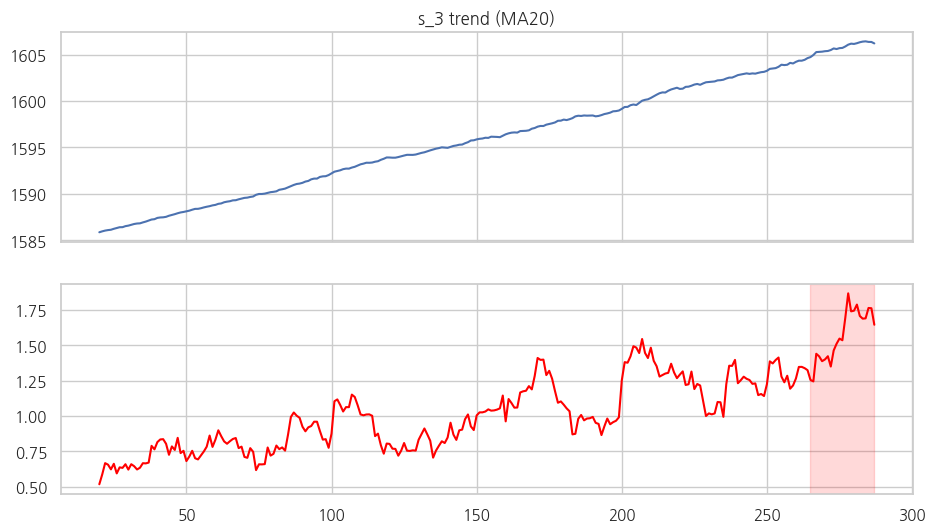

[사실] s_3 변동성이 후반부(265주기 이후) 증가
[사실] s_2-s_4 상관 0.99, s_2-s_7 상관 -0.93
[해석] 후반부 열화 진행 의심 -> 관찰 강화 권고


In [ ]:
# [통계 및 시각화 근거 기반 설비 보전 의사결정 요청용 종합 리포트 생성]
# 1. axes[0].plot(): 20-사이클 이동평균선(ma)을 통해 온도/마찰 센서의 지속적인 우상향(추세)을 증명합니다.
# 2. axes[1].plot() 및 axvspan(): 후반부(265~287 사이클)에 발생한 진폭 팽창(변동성 급증) 현상을 차트상에 경고 박스로 매핑합니다.
# 3. 종합 인쇄문: 앞서 발견한 정량 사실들(상관행렬 결과, 변동 구간)을 텍스트로 구성하고 최종 정비 권고안을 현장에 송출합니다.
# * 머신러닝이나 수식을 통한 기계 예측 과정에서 수치뿐 아니라 원인과 경과를 설명할 수 있는
#   '설명 가능한(Explainable) 예방보전'의 기초 형태를 텍스트 및 차트 리포트로 자동 생성해 줍니다.
# * 리포트 문자열 출력 시, 줄바꿈이나 오타로 인해 코드 블록 문법이 망가지지 않도록 세심하게 텍스트를 인쇄합니다.

ma = e2['s_3'].rolling(20).mean()
sd2 = e2['s_3'].rolling(20).std()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(e2['time_cycles'], ma); axes[0].set_title('s_3 trend (MA20)')
axes[1].plot(e2['time_cycles'], sd2, color='red')
axes[1].axvspan(265, 287, color='red', alpha=0.15)

plt.show()

print('[사실] s_3 변동성이 후반부(265주기 이후) 증가')
print('[사실] s_2-s_4 상관 0.99, s_2-s_7 상관 -0.93')
print('[해석] 후반부 열화 진행 의심 -> 관찰 강화 권고')